# Analysis Continued: Market-Level Recall and Forecast Experiments

This notebook extends `regression_score.ipynb` from domain-level aggregation to market-level tests.

The core question is whether a model's recall ability around a target market predicts its forecast quality on that target. The earlier notebook used one point per model-domain cell. Here we build one point per model-market cell and run fixed-effect analyses that control for the exact market being forecast.

We run the following experiments:

1. Local historical resolved-market experiment: Brier on a resolved target market vs recall accuracy on nearby historical markets.
2. Robustness over neighbor count and distance weighting.
3. Negative controls: shuffled local recall, farthest neighbors, and cross-domain neighbors.
4. Direct same-market recall vs Brier.
5. Recall error-type decomposition.
6. No-direct-recall subset: a feasible proxy for a no-recall-prompt experiment.
7. Open-market proxy: distance from current Polymarket price for future markets.
8. Model-pair comparisons on the same target market.

Conventions:

- Lower Brier is better.
- Negative coefficients on recall mean higher recall is associated with better forecasts.
- The main historical regressions use model fixed effects and target-market fixed effects. This controls market difficulty more tightly than a domain-level entropy control.

In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 130

# Robust path detection: works when run from repo root or Research/analysis.
HERE = Path.cwd().resolve()
if (HERE / "Research").exists():
    REPO_ROOT = HERE
elif HERE.name == "analysis" and HERE.parent.name == "Research":
    REPO_ROOT = HERE.parent.parent
elif (HERE.parent / "Research").exists():
    REPO_ROOT = HERE.parent
else:
    REPO_ROOT = Path("/Users/prashanth/Desktop/AIForecastPaper")

RESEARCH_DIR = REPO_ROOT / "Research"

DOMAINS = [
    "ClimateMarkets",
    "CommoditiesMarkets",
    "CompaniesMarkets",
    "EconomicsMarkets",
    "ElectionsMarkets",
    "EntertainmentMarkets",
    "FinancialsMarkets",
    "PoliticsMarkets",
    "ScienceTechnologyMarkets",
]

SHORT_DOMAIN = {d: d.replace("Markets", "") for d in DOMAINS}

MODEL_DISPLAY = {
    "claude-opus-4-7_1000": "Claude Opus 4.7",
    "claude-sonnet-4-6_1000": "Claude Sonnet 4.6",
    "gemini-3-flash-preview": "Gemini 3 Flash",
    "gemini-3.1-pro-preview": "Gemini 3.1 Pro",
    "gpt-5-4": "GPT-5.4",
    "gpt-5-5": "GPT-5.5",
}

def model_display(model: str) -> str:
    return MODEL_DISPLAY.get(model, model)

def binary_entropy(p: float) -> float:
    p = max(min(float(p), 1 - 1e-12), 1e-12)
    return -p * math.log(p) - (1 - p) * math.log(1 - p)

def normalize_outcome(value):
    if value is None:
        return None
    return str(value).strip().lower()

def is_valid_score(value) -> bool:
    return isinstance(value, (int, float)) and float(value) in {0.0, 0.5, 1.0}

## 1. Load Historical Recall/Forecast Records

What this produces: a market-level panel from the graded recall files. Each row is a model-market observation containing the model's probability, target Brier score when the market resolves Yes/No, and a normalized recall signal.

Important scoring choice: if a file has been graded at all, missing `recall_score` means no usable recall for that item and is treated as `0.0` in the primary recall signal. If the model stated the wrong recalled outcome but the grader left the score blank, we normalize that case to `0.0`. Entire ungraded files, such as files with no valid score anywhere, are excluded from recall-based analyses.

What we hope to see: enough graded model-market observations to support market fixed effects, and clear visibility into which model files are excluded as ungraded.

In [2]:
def parse_probability_yes(payload: dict) -> float:
    value = (payload or {}).get("Yes")
    try:
        return float(value) if value is not None else np.nan
    except (TypeError, ValueError):
        return np.nan

def recall_state_from(raw_score, wrong_recalled: bool) -> str:
    if is_valid_score(raw_score) and float(raw_score) == 1.0:
        return "correct_clean"
    if is_valid_score(raw_score) and float(raw_score) == 0.5:
        return "partial"
    if (is_valid_score(raw_score) and float(raw_score) == 0.0) or wrong_recalled:
        return "confident_wrong"
    return "no_recall"

def normalized_recall_score(raw_score, wrong_recalled: bool) -> float:
    if is_valid_score(raw_score):
        return float(raw_score)
    if wrong_recalled:
        return 0.0
    return 0.0

def normalized_recall_score_excl_null(raw_score, wrong_recalled: bool) -> float:
    if is_valid_score(raw_score):
        return float(raw_score)
    if wrong_recalled:
        return 0.0
    return np.nan

def load_historical_recall_records():
    rows = []
    market_meta = {}
    skipped_files = []
    fixed_wrong_scores = []

    for domain in DOMAINS:
        recall_dir = RESEARCH_DIR / domain / "recall"
        for path in sorted(recall_dir.glob("*.json")):
            model = path.stem.replace("_recall", "")
            items = json.loads(path.read_text())
            file_has_any_score = any(
                is_valid_score(((item.get("forecast") or {}).get("recall_assessment") or {}).get("recall_score"))
                for item in items
            )
            if not file_has_any_score:
                skipped_files.append({"domain": domain, "model": model, "reason": "no valid recall_score anywhere"})
                continue

            for item in items:
                forecast = item.get("forecast") or {}
                recall = forecast.get("recall_assessment") or {}
                probs = forecast.get("probabilities") or {}

                condition_id = item.get("condition_id") or item.get("market_slug")
                actual = item.get("actual_resolution")
                recalled = recall.get("recalled_outcome_if_known")
                raw_score = recall.get("recall_score")
                wrong_recalled = (
                    recalled is not None
                    and actual is not None
                    and normalize_outcome(recalled) != normalize_outcome(actual)
                )
                if wrong_recalled and not is_valid_score(raw_score):
                    fixed_wrong_scores.append({"domain": domain, "model": model, "condition_id": condition_id})

                p_yes = parse_probability_yes(probs)
                outcome = 1.0 if actual == "Yes" else 0.0 if actual == "No" else np.nan
                brier = (p_yes - outcome) ** 2 if not np.isnan(p_yes) and not np.isnan(outcome) else np.nan

                row = {
                    "model": model,
                    "model_display": model_display(model),
                    "domain": domain,
                    "domain_short": SHORT_DOMAIN[domain],
                    "condition_id": condition_id,
                    "market_slug": item.get("market_slug", ""),
                    "event_slug": item.get("event_slug", ""),
                    "title": item.get("title", ""),
                    "category": item.get("category") or SHORT_DOMAIN[domain],
                    "close_time": item.get("close_time", ""),
                    "actual_resolution": actual,
                    "p_yes": p_yes,
                    "brier": brier,
                    "raw_recall_score": raw_score,
                    "recall_score": normalized_recall_score(raw_score, wrong_recalled),
                    "recall_score_excl_null": normalized_recall_score_excl_null(raw_score, wrong_recalled),
                    "recall_state": recall_state_from(raw_score, wrong_recalled),
                    "recognized_event": recall.get("recognized_event"),
                    "wrong_recalled_outcome": wrong_recalled,
                }
                rows.append(row)
                market_meta.setdefault(
                    condition_id,
                    {key: row[key] for key in ["condition_id", "market_slug", "event_slug", "title", "domain", "domain_short", "category", "close_time"]},
                )

    return pd.DataFrame(rows), pd.DataFrame(market_meta.values()), pd.DataFrame(skipped_files), pd.DataFrame(fixed_wrong_scores)

historical_records, historical_markets, skipped_files, fixed_wrong_scores = load_historical_recall_records()
historical_panel = historical_records.dropna(subset=["brier"]).copy()

data_summary = pd.DataFrame({
    "quantity": [
        "graded model-market recall rows",
        "unique historical markets in graded files",
        "historical model-market rows with binary Brier",
        "unique binary-Brier target markets",
        "models included",
        "ungraded files skipped",
        "wrong recalled outcomes normalized to 0.0",
    ],
    "value": [
        len(historical_records),
        historical_markets["condition_id"].nunique(),
        len(historical_panel),
        historical_panel["condition_id"].nunique(),
        historical_records["model"].nunique(),
        len(skipped_files),
        len(fixed_wrong_scores),
    ],
})
display(data_summary)

model_summary = (
    historical_records.groupby(["model", "model_display"])
    .agg(
        rows=("condition_id", "size"),
        brier_rows=("brier", lambda s: s.notna().sum()),
        mean_recall=("recall_score", "mean"),
        mean_recall_graded_only=("recall_score_excl_null", "mean"),
        no_recall_share=("recall_state", lambda s: (s == "no_recall").mean()),
        confident_wrong_share=("recall_state", lambda s: (s == "confident_wrong").mean()),
        mean_brier=("brier", "mean"),
    )
    .reset_index()
    .sort_values("mean_recall", ascending=False)
)
display(model_summary.round(4))

print("Skipped ungraded files by model:")
display(skipped_files.groupby("model").size().rename("files_skipped").reset_index())
print("Observation: the market-level historical panel keeps the four models with graded recall files and excludes fully ungraded recall runs.")

,quantity,value
0,graded model-market recall rows,5200
1,unique historical markets in graded files,1300
2,historical model-market rows with binary Brier,4897
3,unique binary-Brier target markets,1264
4,models included,4
5,ungraded files skipped,18
6,wrong recalled outcomes normalized to 0.0,344


,model,model_display,rows,brier_rows,mean_recall,mean_recall_graded_only,no_recall_share,confident_wrong_share,mean_brier
2,gemini-3.1-pro-preview,Gemini 3.1 Pro,1300,1264,0.6931,0.8689,0.2023,0.0615,0.0821
0,claude-opus-4-7_1000,Claude Opus 4.7,1300,1264,0.6327,0.8376,0.2446,0.0700,0.0949
1,claude-sonnet-4-6_1000,Claude Sonnet 4.6,1300,1264,0.6127,0.7507,0.1838,0.1331,0.1311
3,gpt-5-5,GPT-5.5,1300,1105,0.6062,0.8864,0.3162,0.0577,0.0756


Skipped ungraded files by model:


,model,files_skipped
0,gemini-3-flash-preview,9
1,gpt-5-4,9


Observation: the market-level historical panel keeps the four models with graded recall files and excludes fully ungraded recall runs.


## 2. Build Text Similarity and Local Recall Features

What this produces: for each target market, a ranked list of nearby historical markets based on TF-IDF cosine similarity over title, category, domain, event slug, and market slug. For the historical leave-one-out version, the target market itself and same `event_slug` markets are excluded from its neighbor set.

Why this is the local experiment: instead of asking whether a model is generally good at a whole domain, we ask whether its recall on the target's nearest neighbors predicts forecast quality on that exact target.

What we hope to see: nearest-neighbor titles should look substantively related, not just from the same broad category.

In [3]:
def tokenize_market_text(text: str) -> list[str]:
    tokens = re.findall(r"[a-z0-9]+", str(text).lower())
    bigrams = ["_".join(pair) for pair in zip(tokens, tokens[1:])]
    return tokens + bigrams

def market_text(row: pd.Series) -> str:
    fields = ["title", "category", "domain", "event_slug", "market_slug"]
    return " ".join(str(row.get(field, "")) for field in fields)

def tfidf_matrix(markets_df: pd.DataFrame, min_df: int = 2):
    docs = [tokenize_market_text(market_text(row)) for _, row in markets_df.iterrows()]
    doc_freq = Counter()
    for tokens in docs:
        doc_freq.update(set(tokens))
    terms = [term for term, count in sorted(doc_freq.items()) if count >= min_df]
    vocab = {term: idx for idx, term in enumerate(terms)}
    n_docs = len(docs)
    matrix = np.zeros((n_docs, len(vocab)), dtype=np.float32)
    idf = {term: math.log((1 + n_docs) / (1 + doc_freq[term])) + 1 for term in vocab}

    for row_idx, tokens in enumerate(docs):
        counts = Counter(term for term in tokens if term in vocab)
        for term, count in counts.items():
            matrix[row_idx, vocab[term]] = (1 + math.log(count)) * idf[term]

    norms = np.linalg.norm(matrix, axis=1)
    norms[norms == 0] = 1.0
    return matrix / norms[:, None], vocab

def build_historical_neighbor_sets(markets_df: pd.DataFrame, similarity: np.ndarray):
    near, far, cross_domain = {}, {}, {}
    for i, row in markets_df.reset_index(drop=True).iterrows():
        sims = similarity[i].copy()
        sims[i] = -1.0
        same_event = (markets_df["event_slug"] == row["event_slug"]) & (markets_df["event_slug"] != "")
        sims[same_event.values] = -1.0

        desc = [j for j in np.argsort(-sims) if sims[j] >= 0]
        asc = [j for j in np.argsort(sims) if sims[j] >= 0]

        cid = row["condition_id"]
        near[cid] = [(markets_df["condition_id"].iloc[j], float(sims[j])) for j in desc]
        far[cid] = [(markets_df["condition_id"].iloc[j], float(sims[j])) for j in asc]
        cross_domain[cid] = [
            (markets_df["condition_id"].iloc[j], float(sims[j]))
            for j in desc
            if markets_df["domain"].iloc[j] != row["domain"]
        ]
    return {"local": near, "far": far, "cross": cross_domain}

hist_X, hist_vocab = tfidf_matrix(historical_markets)
hist_similarity = hist_X @ hist_X.T
hist_neighbor_sets = build_historical_neighbor_sets(historical_markets.reset_index(drop=True), hist_similarity)

score_map = {(row.model, row.condition_id): row.recall_score for row in historical_records.itertuples()}
state_map = {(row.model, row.condition_id): row.recall_state for row in historical_records.itertuples()}

def local_recall_stats(model: str, condition_id: str, k: int, neighbor_lookup: dict) -> dict:
    values, sims, states = [], [], []
    for neighbor_id, sim in neighbor_lookup.get(condition_id, []):
        key = (model, neighbor_id)
        if key not in score_map:
            continue
        values.append(score_map[key])
        sims.append(sim)
        states.append(state_map[key])
        if len(values) >= k:
            break

    if not values:
        return {
            "R": np.nan,
            "R_weighted": np.nan,
            "mean_similarity": np.nan,
            "n_neighbors": 0,
            "correct_share": np.nan,
            "partial_share": np.nan,
            "wrong_share": np.nan,
            "no_recall_share": np.nan,
        }

    weights = np.maximum(np.array(sims, dtype=float), 0.0)
    weighted = np.average(values, weights=weights) if weights.sum() > 0 else np.mean(values)
    counts = Counter(states)
    n = len(values)
    return {
        "R": float(np.mean(values)),
        "R_weighted": float(weighted),
        "mean_similarity": float(np.mean(sims)),
        "n_neighbors": n,
        "correct_share": counts["correct_clean"] / n,
        "partial_share": counts["partial"] / n,
        "wrong_share": counts["confident_wrong"] / n,
        "no_recall_share": counts["no_recall"] / n,
    }

def add_local_features(panel: pd.DataFrame, neighbor_sets: dict, ks=(3, 5, 10, 20, 50)) -> pd.DataFrame:
    out = panel.copy()
    for k in ks:
        for label, lookup in neighbor_sets.items():
            stats = [local_recall_stats(row.model, row.condition_id, k, lookup) for row in out.itertuples()]
            out[f"R_{label}_{k}"] = [s["R"] for s in stats]
            out[f"R_{label}_w_{k}"] = [s["R_weighted"] for s in stats]
            out[f"sim_{label}_{k}"] = [s["mean_similarity"] for s in stats]
            out[f"n_{label}_{k}"] = [s["n_neighbors"] for s in stats]
            if label == "local":
                out[f"local_correct_{k}"] = [s["correct_share"] for s in stats]
                out[f"local_partial_{k}"] = [s["partial_share"] for s in stats]
                out[f"local_wrong_{k}"] = [s["wrong_share"] for s in stats]
                out[f"local_no_recall_{k}"] = [s["no_recall_share"] for s in stats]
    return out

historical_panel = add_local_features(historical_panel, hist_neighbor_sets)

sample_market = historical_markets.sample(1, random_state=3).iloc[0]
print("Example target market:")
print(" ", sample_market["title"])
print("Nearest historical neighbors, excluding same event_slug:")
for neighbor_id, sim in hist_neighbor_sets["local"][sample_market["condition_id"]][:8]:
    neighbor = historical_markets.loc[historical_markets["condition_id"] == neighbor_id].iloc[0]
    print(f"  sim={sim:.3f} | {neighbor['domain_short']}: {neighbor['title']}")

Example target market:
  Will the Independence Party win the most seats in the Icelandic parliamentary election?
Nearest historical neighbors, excluding same event_slug:
  sim=0.875 | Elections: Will another party win the most seats in the Ghanaian parliamentary election?
  sim=0.845 | Elections: Will another party win the most seats in the Romanian parliamentary election?
  sim=0.759 | Elections: Will another party win the most seats in the 2024 Sri Lankan Parliamentary elections?
  sim=0.720 | Elections: Will LSDP win the most seats in the 2024 Lithuania legislative election?
  sim=0.710 | Elections: Will SPÖ win the most seats in the 2024 Austrian legislative election?
  sim=0.678 | Elections: Will the Constitutional Democratic Party win the most seats in the 2024 Japanese general election?
  sim=0.643 | Elections: Will CD&V win the most seats in the Belgian federal elections?
  sim=0.627 | Elections: Will another party win the most seats in the 2024 Saskatchewan general election?


## 3. Fixed-Effect Regression Helper

What this produces: a fast fixed-effect estimator. Instead of expanding thousands of `C(condition_id)` dummies, we residualize the outcome and predictors against the requested fixed effects, then run OLS on the residualized variables.

For the main regressions, the fixed effects are:

- `model`: controls each model's overall forecasting quality.
- `condition_id`: controls the exact target market. This is the strongest available control for market difficulty because all models are compared on the same market.

Standard errors are clustered by target market.

In [4]:
def residualize_matrix(values: np.ndarray, groups: list[pd.Series], max_iter: int = 50, tol: float = 1e-10) -> np.ndarray:
    """Residualize columns in values against one or more sets of fixed effects."""
    frame = pd.DataFrame(np.asarray(values, dtype=float)).reset_index(drop=True)
    frame = frame - frame.mean(axis=0)
    group_series = [pd.Series(group).reset_index(drop=True) for group in groups]

    for _ in range(max_iter):
        previous = frame.to_numpy(copy=True)
        for labels in group_series:
            frame = frame - frame.groupby(labels).transform("mean")
        if np.max(np.abs(frame.to_numpy() - previous)) < tol:
            break
    return frame.to_numpy()

def fe_ols(
    data: pd.DataFrame,
    y: str,
    xs: list[str],
    fixed_effects=("model", "condition_id"),
    cluster: str = "condition_id",
    label: str | None = None,
) -> tuple[pd.DataFrame, object, pd.DataFrame]:
    needed = []
    for col in [y] + xs + list(fixed_effects) + [cluster]:
        if col not in needed:
            needed.append(col)
    df = data[needed].dropna().copy()
    if df.empty:
        raise ValueError(f"No complete rows for {label or xs}")

    residualized = residualize_matrix(df[[y] + xs].to_numpy(float), [df[fe] for fe in fixed_effects])
    y_resid = residualized[:, 0]
    x_resid = residualized[:, 1:]

    keep = [idx for idx in range(x_resid.shape[1]) if np.std(x_resid[:, idx]) > 1e-12]
    kept_terms = [xs[idx] for idx in keep]
    if not keep:
        raise ValueError(f"All predictors were absorbed by fixed effects for {label or xs}")

    result = sm.OLS(y_resid, x_resid[:, keep]).fit(
        cov_type="cluster",
        cov_kwds={"groups": df[cluster]},
    )
    table = pd.DataFrame(
        {
            "analysis": label or " + ".join(xs),
            "term": kept_terms,
            "coef": result.params,
            "se": result.bse,
            "p": result.pvalues,
            "nobs": int(result.nobs),
            "clusters": df[cluster].nunique(),
            "r2_within": result.rsquared,
            "fixed_effects": "+".join(fixed_effects),
        }
    )
    return table, result, df

def pretty_regression_table(table: pd.DataFrame) -> pd.DataFrame:
    out = table.copy()
    for col in ["coef", "se", "p", "r2_within"]:
        out[col] = out[col].astype(float).map(lambda x: f"{x:.4f}")
    return out

def print_effect_read(table: pd.DataFrame, term: str, outcome_label: str = "Brier"):
    row = table.loc[table["term"] == term].iloc[0]
    direction = "better/lower" if row["coef"] < 0 else "worse/higher"
    print(
        f"Observed: beta({term}) = {row['coef']:.4f}, SE = {row['se']:.4f}, "
        f"p = {row['p']:.4g}. Higher {term} is associated with {direction} {outcome_label}."
    )

## 4. Main Experiment: Local Recall on Historical Resolved Targets

What this produces: the central test. For each model-target row, compute the model's recall score on the 10 nearest historical neighbors, then regress target Brier on that local recall score.

Main specification:

\[
Brier_{m,i} = \beta R^{local}_{m,i,k=10} + \alpha_m + \delta_i + \epsilon_{m,i}
\]

What we hope to see: a negative coefficient. That would mean models forecast a target market better when they recall nearby historical analogs better, even after comparing models on the exact same target market.

In [5]:
main_table, _, main_df = fe_ols(
    historical_panel,
    y="brier",
    xs=["R_local_10"],
    fixed_effects=("model", "condition_id"),
    cluster="condition_id",
    label="Historical local recall, k=10, market FE",
)
weighted_table, _, _ = fe_ols(
    historical_panel,
    y="brier",
    xs=["R_local_w_10"],
    fixed_effects=("model", "condition_id"),
    cluster="condition_id",
    label="Historical weighted local recall, k=10, market FE",
)
domain_fe_table, _, _ = fe_ols(
    historical_panel,
    y="brier",
    xs=["R_local_10"],
    fixed_effects=("model", "domain"),
    cluster="condition_id",
    label="Historical local recall, k=10, domain FE",
)

main_results = pd.concat([main_table, weighted_table, domain_fe_table], ignore_index=True)
display(pretty_regression_table(main_results))
print_effect_read(main_table, "R_local_10")
print("Interpretation: market fixed effects make this a within-market, across-model comparison. The coefficient is smaller than the domain-level result, but it is a more demanding test.")

,analysis,term,coef,se,p,nobs,clusters,r2_within,fixed_effects
0,"Historical local recall, k=10, market FE",R_local_10,-0.0652,0.0231,0.0048,4897,1264,0.0029,model+condition_id
1,"Historical weighted local recall, k=10, market FE",R_local_w_10,-0.0710,0.0225,0.0016,4897,1264,0.0039,model+condition_id
2,"Historical local recall, k=10, domain FE",R_local_10,-0.2031,0.0281,0.0000,4897,1264,0.0306,model+domain


Observed: beta(R_local_10) = -0.0652, SE = 0.0231, p = 0.004757. Higher R_local_10 is associated with better/lower Brier.
Interpretation: market fixed effects make this a within-market, across-model comparison. The coefficient is smaller than the domain-level result, but it is a more demanding test.


## 5. Robustness: Neighbor Count and Distance Weighting

What this produces: the main fixed-effect regression repeated for several neighborhood sizes and for unweighted vs similarity-weighted local recall.

What we hope to see: coefficients should generally remain negative. A clean local-memory story would usually produce stronger results for closer neighborhoods, but in sparse data larger `k` can reduce measurement noise and strengthen the estimate.

,analysis,term,coef,se,p,nobs,clusters,r2_within,k,weighted
0,"k=3, unweighted",R_local_3,-0.0425,0.0147,0.0039,4897,1264,0.0031,3,False
1,"k=3, weighted",R_local_w_3,-0.0449,0.0148,0.0024,4897,1264,0.0037,3,True
2,"k=5, unweighted",R_local_5,-0.0501,0.0171,0.0033,4897,1264,0.0028,5,False
3,"k=5, weighted",R_local_w_5,-0.0553,0.0174,0.0015,4897,1264,0.0037,5,True
4,"k=10, unweighted",R_local_10,-0.0652,0.0231,0.0048,4897,1264,0.0029,10,False
5,"k=10, weighted",R_local_w_10,-0.0710,0.0225,0.0016,4897,1264,0.0039,10,True
6,"k=20, unweighted",R_local_20,-0.0984,0.0252,0.0001,4897,1264,0.0042,20,False
7,"k=20, weighted",R_local_w_20,-0.1020,0.0264,0.0001,4897,1264,0.0053,20,True
8,"k=50, unweighted",R_local_50,-0.1211,0.0341,0.0004,4897,1264,0.0035,50,False
9,"k=50, weighted",R_local_w_50,-0.1297,0.0324,0.0001,4897,1264,0.0053,50,True


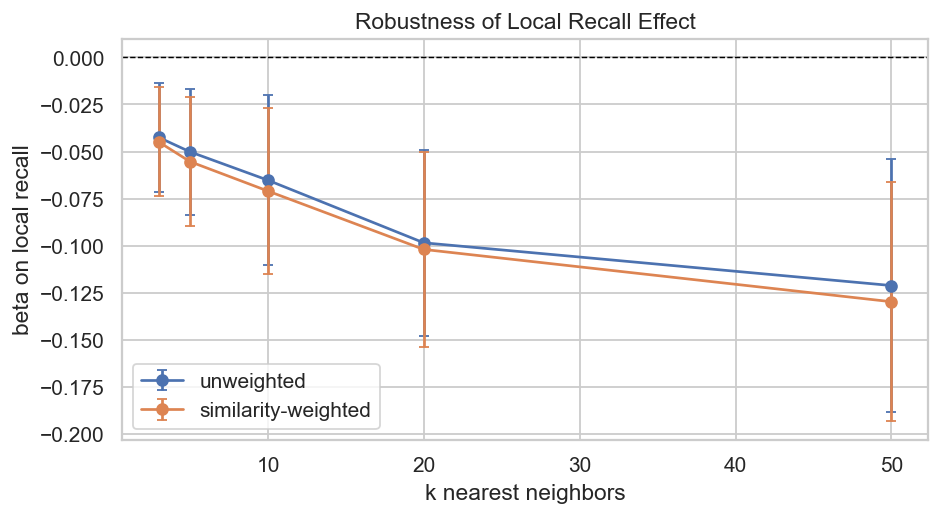

Observed: 100% of robustness specifications have negative coefficients.


In [6]:
robust_rows = []
for k in [3, 5, 10, 20, 50]:
    for weighted, col in [(False, f"R_local_{k}"), (True, f"R_local_w_{k}")]:
        table, _, _ = fe_ols(
            historical_panel,
            y="brier",
            xs=[col],
            fixed_effects=("model", "condition_id"),
            cluster="condition_id",
            label=f"k={k}, {'weighted' if weighted else 'unweighted'}",
        )
        row = table.iloc[0].to_dict()
        row["k"] = k
        row["weighted"] = weighted
        robust_rows.append(row)

robustness = pd.DataFrame(robust_rows)
display(pretty_regression_table(robustness[["analysis", "term", "coef", "se", "p", "nobs", "clusters", "r2_within", "k", "weighted"]]))

fig, ax = plt.subplots(figsize=(8, 4))
for weighted, grp in robustness.groupby("weighted"):
    label = "similarity-weighted" if weighted else "unweighted"
    ax.errorbar(grp["k"], grp["coef"], yerr=1.96 * grp["se"], marker="o", capsize=3, label=label)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("k nearest neighbors")
ax.set_ylabel("beta on local recall")
ax.set_title("Robustness of Local Recall Effect")
ax.legend()
plt.show()

neg_share = (robustness["coef"] < 0).mean()
print(f"Observed: {neg_share:.0%} of robustness specifications have negative coefficients.")

## 6. Negative Controls

What this produces: three falsification checks using the same fixed-effect estimator.

- Shuffled local recall: local recall scores are permuted within model.
- Farthest neighbors: use the least similar historical markets.
- Cross-domain neighbors: use nearest markets outside the target's domain.

What we hope to see: the real local-neighbor signal should be stronger than these controls, and the controls should move toward zero.

,analysis,term,coef,se,p,nobs,clusters,r2_within,fixed_effects
0,True local neighbors,R_local_10,-0.0652,0.0231,0.0048,4897,1264,0.0029,model+condition_id
0,Shuffled within model,R_local_10_shuffled,0.0081,0.0106,0.4472,4897,1264,0.0002,model+condition_id
0,Farthest neighbors,R_far_10,0.0136,0.0216,0.5302,4897,1264,0.0001,model+condition_id
0,Nearest cross-domain neighbors,R_cross_10,-0.0241,0.0210,0.2510,4897,1264,0.0003,model+condition_id


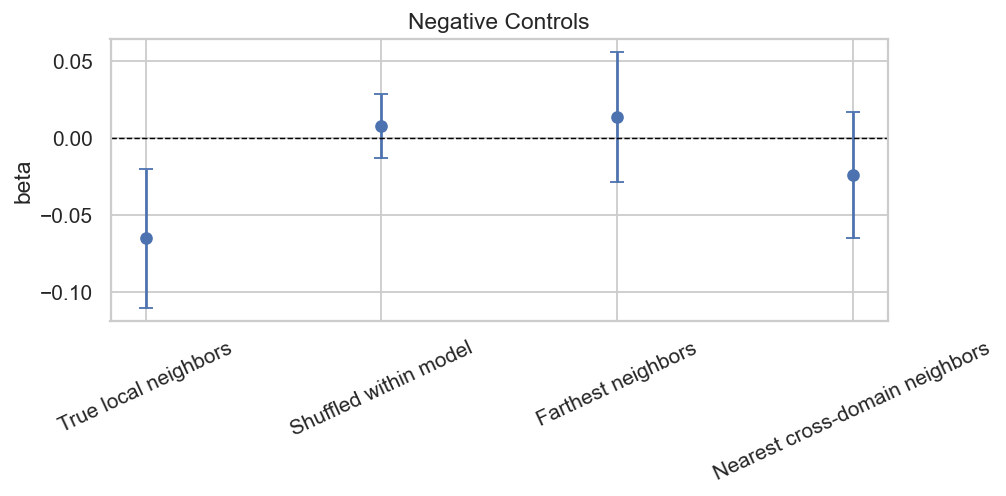

Observed: true local beta = -0.0652; control betas range from -0.0241 to 0.0136.


In [7]:
rng = np.random.default_rng(2026)
negative_panel = historical_panel.copy()
shuffled = np.empty(len(negative_panel))
for _, index_values in negative_panel.groupby("model").indices.items():
    index_values = np.array(list(index_values))
    shuffled[index_values] = rng.permutation(negative_panel.iloc[index_values]["R_local_10"].to_numpy())
negative_panel["R_local_10_shuffled"] = shuffled

negative_specs = [
    ("True local neighbors", "R_local_10"),
    ("Shuffled within model", "R_local_10_shuffled"),
    ("Farthest neighbors", "R_far_10"),
    ("Nearest cross-domain neighbors", "R_cross_10"),
]
negative_rows = []
for label, col in negative_specs:
    table, _, _ = fe_ols(
        negative_panel,
        y="brier",
        xs=[col],
        fixed_effects=("model", "condition_id"),
        cluster="condition_id",
        label=label,
    )
    negative_rows.append(table.iloc[0])
negative_results = pd.DataFrame(negative_rows)
display(pretty_regression_table(negative_results))

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    negative_results["analysis"],
    negative_results["coef"],
    yerr=1.96 * negative_results["se"],
    fmt="o",
    capsize=4,
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("beta")
ax.set_title("Negative Controls")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

true_beta = negative_results.loc[negative_results["analysis"] == "True local neighbors", "coef"].iloc[0]
control_betas = negative_results.loc[negative_results["analysis"] != "True local neighbors", "coef"]
print(f"Observed: true local beta = {true_beta:.4f}; control betas range from {control_betas.min():.4f} to {control_betas.max():.4f}.")

## 7. Direct Same-Market Recall

What this produces: a more direct but less causally clean test. We regress target Brier on the model's own recall score for that same target market.

What we hope to see: a strongly negative coefficient. This should be interpreted carefully because the recall prompt explicitly invited the model to use remembered resolution facts; when it remembers the exact outcome, the probability forecast can become nearly deterministic.

In [8]:
direct_table, _, _ = fe_ols(
    historical_panel,
    y="brier",
    xs=["recall_score"],
    fixed_effects=("model", "condition_id"),
    cluster="condition_id",
    label="Direct same-market recall score",
)

direct_state_panel = historical_panel.copy()
for state in ["partial", "confident_wrong", "no_recall"]:
    direct_state_panel[f"state_{state}"] = (direct_state_panel["recall_state"] == state).astype(float)

state_table, _, _ = fe_ols(
    direct_state_panel,
    y="brier",
    xs=["state_partial", "state_confident_wrong", "state_no_recall"],
    fixed_effects=("model", "condition_id"),
    cluster="condition_id",
    label="Direct recall state, reference=correct_clean",
)

display(pretty_regression_table(pd.concat([direct_table, state_table], ignore_index=True)))
print_effect_read(direct_table, "recall_score")
print("Observed state coefficients are relative to correct-clean recall. Large positive values for confident-wrong or no-recall mean those states have worse Brier than clean recall on the same market.")

,analysis,term,coef,se,p,nobs,clusters,r2_within,fixed_effects
0,Direct same-market recall score,recall_score,-0.2165,0.0142,0.0000,4897,1264,0.1907,model+condition_id
1,"Direct recall state, reference=correct_clean",state_partial,-0.0030,0.0039,0.4426,4897,1264,0.6685,model+condition_id
2,"Direct recall state, reference=correct_clean",state_confident_wrong,0.6806,0.0192,0.0000,4897,1264,0.6685,model+condition_id
3,"Direct recall state, reference=correct_clean",state_no_recall,0.1173,0.0097,0.0000,4897,1264,0.6685,model+condition_id


Observed: beta(recall_score) = -0.2165, SE = 0.0142, p = 1.048e-52. Higher recall_score is associated with better/lower Brier.
Observed state coefficients are relative to correct-clean recall. Large positive values for confident-wrong or no-recall mean those states have worse Brier than clean recall on the same market.


## 8. Local Error-Type Decomposition

What this produces: a decomposition of the local neighborhood into shares of clean recall, partial recall, confident wrong recall, and no recall. The regression includes clean, confident-wrong, and no-recall shares; partial recall is the omitted reference category.

What we hope to see: local confident-wrong recall should be worse than mere low recall if hallucinated memory is especially damaging.

In [9]:
decomp_table, _, _ = fe_ols(
    historical_panel,
    y="brier",
    xs=["local_correct_10", "local_wrong_10", "local_no_recall_10"],
    fixed_effects=("model", "condition_id"),
    cluster="condition_id",
    label="Local error-type shares, k=10, reference=partial share",
)
display(pretty_regression_table(decomp_table))
print("Observation: positive local_wrong or local_no_recall coefficients mean neighborhoods dominated by those states are associated with worse target Brier, relative to neighborhoods with more partial recall.")

,analysis,term,coef,se,p,nobs,clusters,r2_within,fixed_effects
0,"Local error-type shares, k=10, reference=parti...",local_correct_10,0.0146,0.0297,0.6223,4897,1264,0.0075,model+condition_id
1,"Local error-type shares, k=10, reference=parti...",local_wrong_10,0.1996,0.0549,0.0003,4897,1264,0.0075,model+condition_id
2,"Local error-type shares, k=10, reference=parti...",local_no_recall_10,0.0659,0.0321,0.0405,4897,1264,0.0075,model+condition_id


Observation: positive local_wrong or local_no_recall coefficients mean neighborhoods dominated by those states are associated with worse target Brier, relative to neighborhoods with more partial recall.


## 9. No-Direct-Recall Subset

What this produces: a feasible proxy for a true no-recall-prompt experiment. We restrict to target rows where the model did not recall the target itself, then test whether local recall on neighbors still predicts Brier.

What we hope to see: if local recall captures transferable domain-specific memory rather than direct memorization of the exact answer, it should remain negative even when same-market recall is absent. If the effect disappears, much of the signal may be direct recall rather than transferable local competence.

A true no-recall-prompt experiment would require a second historical model run with a forecasting-only prompt; those historical no-recall-prompt files are not present in the repository, so this subset analysis is the implementable version using existing outputs.

In [10]:
no_direct_panel = historical_panel[historical_panel["recall_state"] == "no_recall"].copy()
no_direct_table, _, no_direct_df = fe_ols(
    no_direct_panel,
    y="brier",
    xs=["R_local_10"],
    fixed_effects=("model", "condition_id"),
    cluster="condition_id",
    label="Local recall among target no-recall rows",
)
display(pretty_regression_table(no_direct_table))
print(f"Rows in no-direct-recall subset: {len(no_direct_df):,}; target markets: {no_direct_df['condition_id'].nunique():,}.")
print_effect_read(no_direct_table, "R_local_10")

,analysis,term,coef,se,p,nobs,clusters,r2_within,fixed_effects
0,Local recall among target no-recall rows,R_local_10,0.0383,0.0463,0.4084,1005,498,0.0017,model+condition_id


Rows in no-direct-recall subset: 1,005; target markets: 498.
Observed: beta(R_local_10) = 0.0383, SE = 0.0463, p = 0.4084. Higher R_local_10 is associated with worse/higher Brier.


## 10. Open-Market Forecast Proxy

What this produces: the same local-recall idea applied to future/open forecast files. These markets do not have true outcomes yet, so the outcome is not Brier against reality. Instead, we use distance from the current Polymarket price:

\[
(model\_p_{Yes} - market\_p_{Yes})^2
\]

What we hope to see: if local recall helps forecasting, models with better local historical recall might stay closer to market prices. This is only a proxy; markets can be wrong, stale, or liquidity-biased.

In [11]:
def load_open_forecast_records(models_to_keep: set[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    market_meta = {}
    for domain in DOMAINS:
        forecast_dir = RESEARCH_DIR / domain / "forecast"
        for path in sorted(forecast_dir.glob("*.json")):
            model = path.stem.replace("_fc", "")
            if model not in models_to_keep:
                continue
            items = json.loads(path.read_text())
            for item in items:
                forecast = item.get("forecast") or {}
                p_model = parse_probability_yes(forecast.get("probabilities") or {})
                market_price = item.get("market_price") or {}
                p_market = parse_probability_yes(market_price)
                if np.isnan(p_model) or np.isnan(p_market):
                    continue
                condition_id = item.get("condition_id") or item.get("market_slug")
                row = {
                    "model": model,
                    "model_display": model_display(model),
                    "domain": domain,
                    "domain_short": SHORT_DOMAIN[domain],
                    "condition_id": condition_id,
                    "market_slug": item.get("market_slug", ""),
                    "event_slug": item.get("event_slug", ""),
                    "title": item.get("title", ""),
                    "category": item.get("category") or SHORT_DOMAIN[domain],
                    "close_time": item.get("close_time", ""),
                    "p_model_yes": p_model,
                    "p_market_yes": p_market,
                    "proxy_brier_market": (p_model - p_market) ** 2,
                    "abs_diff_market": abs(p_model - p_market),
                    "market_entropy": binary_entropy(p_market),
                }
                rows.append(row)
                market_meta.setdefault(
                    condition_id,
                    {key: row[key] for key in ["condition_id", "market_slug", "event_slug", "title", "domain", "domain_short", "category", "close_time"]},
                )
    return pd.DataFrame(rows), pd.DataFrame(market_meta.values())

def build_target_source_neighbors(target_markets: pd.DataFrame, source_markets: pd.DataFrame, target_source_similarity: np.ndarray) -> dict:
    lookup = {}
    for i, row in target_markets.reset_index(drop=True).iterrows():
        sims = target_source_similarity[i].copy()
        # If a future market happens to share an event slug with a historical market, exclude that exact event family.
        if row.get("event_slug", ""):
            same_event = source_markets["event_slug"] == row["event_slug"]
            sims[same_event.values] = -1.0
        order = [j for j in np.argsort(-sims) if sims[j] >= 0]
        lookup[row["condition_id"]] = [(source_markets["condition_id"].iloc[j], float(sims[j])) for j in order]
    return lookup

models_with_graded_recall = set(historical_records["model"].unique())
open_records, open_markets = load_open_forecast_records(models_with_graded_recall)

combined_markets = pd.concat([historical_markets, open_markets], ignore_index=True, sort=False)
combined_X, _ = tfidf_matrix(combined_markets)
hist_count = len(historical_markets)
open_X = combined_X[hist_count:]
hist_X_for_open = combined_X[:hist_count]
open_hist_similarity = open_X @ hist_X_for_open.T
open_neighbor_lookup = build_target_source_neighbors(open_markets.reset_index(drop=True), historical_markets.reset_index(drop=True), open_hist_similarity)
open_neighbor_sets = {"local": open_neighbor_lookup, "far": open_neighbor_lookup, "cross": open_neighbor_lookup}
open_panel = add_local_features(open_records, open_neighbor_sets, ks=(10,))

open_summary = pd.DataFrame({
    "quantity": ["open model-market proxy rows", "unique open markets", "models", "mean squared distance from market"],
    "value": [len(open_panel), open_panel["condition_id"].nunique(), open_panel["model"].nunique(), open_panel["proxy_brier_market"].mean()],
})
display(open_summary)

open_market_fe_table, _, _ = fe_ols(
    open_panel,
    y="proxy_brier_market",
    xs=["R_local_10"],
    fixed_effects=("model", "condition_id"),
    cluster="condition_id",
    label="Open-market proxy, market FE",
)
open_domain_fe_table, _, _ = fe_ols(
    open_panel,
    y="proxy_brier_market",
    xs=["R_local_10", "market_entropy"],
    fixed_effects=("model", "domain"),
    cluster="condition_id",
    label="Open-market proxy, domain FE + entropy",
)
open_abs_table, _, _ = fe_ols(
    open_panel,
    y="abs_diff_market",
    xs=["R_local_10"],
    fixed_effects=("model", "condition_id"),
    cluster="condition_id",
    label="Open-market absolute distance, market FE",
)
open_results = pd.concat([open_market_fe_table, open_domain_fe_table, open_abs_table], ignore_index=True)
display(pretty_regression_table(open_results))
print_effect_read(open_market_fe_table, "R_local_10", outcome_label="squared distance from market price")

,quantity,value
0,open model-market proxy rows,5724.000000
1,unique open markets,1897.000000
2,models,4.000000
3,mean squared distance from market,0.069188


,analysis,term,coef,se,p,nobs,clusters,r2_within,fixed_effects
0,"Open-market proxy, market FE",R_local_10,-0.0284,0.0108,0.0083,5724,1897,0.0017,model+condition_id
1,"Open-market proxy, domain FE + entropy",R_local_10,0.0071,0.0154,0.6419,5724,1897,0.0131,model+domain
2,"Open-market proxy, domain FE + entropy",market_entropy,0.0721,0.0137,0.0000,5724,1897,0.0131,model+domain
3,"Open-market absolute distance, market FE",R_local_10,-0.0448,0.0152,0.0032,5724,1897,0.0020,model+condition_id


Observed: beta(R_local_10) = -0.0284, SE = 0.0108, p = 0.008341. Higher R_local_10 is associated with better/lower squared distance from market price.


## 11. Model-Pair Comparison

What this produces: pairwise within-market comparisons. For a fixed target market and a fixed pair of models, we compute:

- `local_R_diff = local_R_model_A - local_R_model_B`
- `brier_diff = brier_model_A - brier_model_B`

Then we regress `brier_diff` on `local_R_diff` with model-pair and market fixed effects.

What we hope to see: a negative coefficient. If model A has higher local recall than model B on the same target, model A should tend to have lower Brier.

In [12]:
def build_pairwise_panel(panel: pd.DataFrame, local_col: str = "R_local_10") -> pd.DataFrame:
    rows = []
    available_models = sorted(panel["model"].unique())
    indexed = panel.set_index(["condition_id", "model"])

    for condition_id, group in panel.groupby("condition_id"):
        models_here = sorted(group["model"].unique())
        for model_a, model_b in combinations(models_here, 2):
            row_a = indexed.loc[(condition_id, model_a)]
            row_b = indexed.loc[(condition_id, model_b)]
            rows.append(
                {
                    "condition_id": condition_id,
                    "pair": f"{model_display(model_a)} vs {model_display(model_b)}",
                    "model_a": model_a,
                    "model_b": model_b,
                    "local_R_diff": row_a[local_col] - row_b[local_col],
                    "brier_diff": row_a["brier"] - row_b["brier"],
                    "domain": row_a["domain"],
                }
            )
    return pd.DataFrame(rows)

pair_panel = build_pairwise_panel(historical_panel)
pair_table, _, pair_df = fe_ols(
    pair_panel,
    y="brier_diff",
    xs=["local_R_diff"],
    fixed_effects=("pair", "condition_id"),
    cluster="condition_id",
    label="Model-pair local recall difference",
)

non_ties = pair_panel[(pair_panel["local_R_diff"] != 0) & (pair_panel["brier_diff"] != 0)].copy()
non_ties["higher_local_recall_has_lower_brier"] = non_ties["local_R_diff"] * non_ties["brier_diff"] < 0
hit_rate = non_ties["higher_local_recall_has_lower_brier"].mean()

display(pretty_regression_table(pair_table))
print(f"Pair rows: {len(pair_df):,}; markets: {pair_df['condition_id'].nunique():,}; model pairs: {pair_df['pair'].nunique():,}.")
print(f"Directional hit rate among non-ties: {hit_rate:.1%}.")
print_effect_read(pair_table, "local_R_diff", outcome_label="Brier difference")

,analysis,term,coef,se,p,nobs,clusters,r2_within,fixed_effects
0,Model-pair local recall difference,local_R_diff,-0.0741,0.0261,0.0045,7107,1264,0.0039,pair+condition_id


Pair rows: 7,107; markets: 1,264; model pairs: 6.
Directional hit rate among non-ties: 60.2%.
Observed: beta(local_R_diff) = -0.0741, SE = 0.0261, p = 0.004539. Higher local_R_diff is associated with better/lower Brier difference.


## 12. Overall Read

The most important result is the historical local-neighbor experiment with market fixed effects. It tests a substantially more compelling claim than domain aggregation: after controlling for the exact target market and each model's average skill, local recall around that target still predicts forecast quality.

How to read the notebook:

- If the main local coefficient is negative and survives the negative controls, the evidence supports a local relationship between recall and forecasting.
- If direct same-market recall is much stronger than local recall, that is expected; direct recall can reveal the actual answer.
- If the no-direct-recall subset weakens, then much of the available signal may come from direct memory rather than transferable nearby competence.
- If the open-market proxy differs from the historical result, remember that it is measuring agreement with market price, not accuracy against final resolution.

The follow-up that would most cleanly separate memory from forecasting skill is to run a second historical forecasting pass with a prompt that does not ask for recall, then repeat Sections 4-6 on those probabilities.